In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy
sy.init_printing() 
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)


|     |                     |
|----------------|-------------------------------|
|  Tugas Proyek   |  Aljabar Linear                |
| Nama           | Kevin Synagogue Panjaitan     |
| NIM            | F1C221058                     |




## Pendahuluan

Kita mulai dengan mempelajari dasar-dasar pembuatan plot (grafik) di Python, sambil sekaligus meninjau kembali konsep sistem persamaan linear.


# <font face="gotham" color="purple"> Visualisasi Sistem Persamaan Linear  </font>

## Sistem Persamaan Linear Sederhana

Pertimbangkan sebuah sistem persamaan linear dua variabel berikut:

\[
\begin{align}
x + y &= 6 \\
x - y &= -4
\end{align}
\]

Sistem ini mudah diselesaikan, menghasilkan:
\[
(x, y)^T = (1, 5)^T
\]

Mari kita visualisasikan sistem persamaan linear ini dalam bentuk grafik.


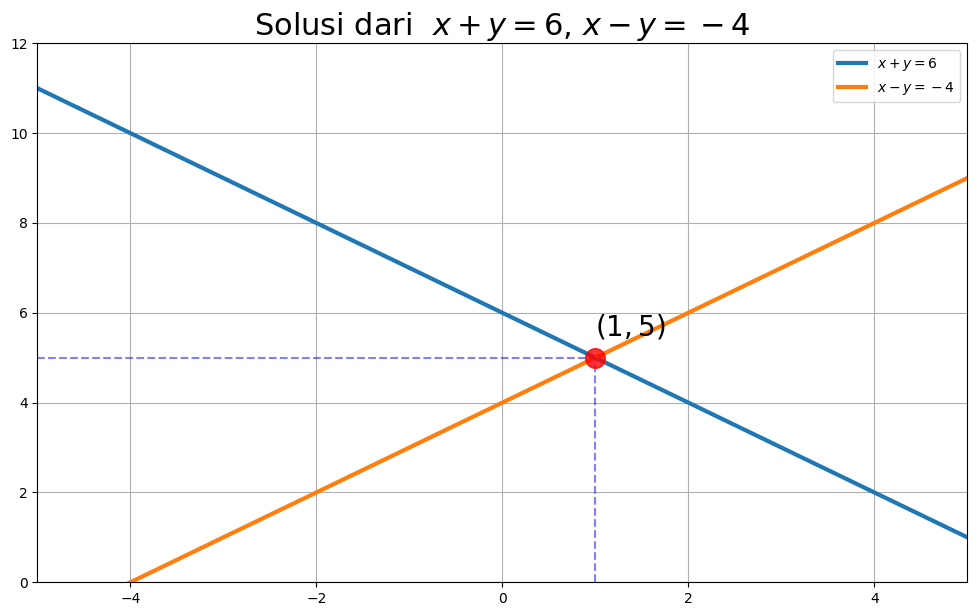

In [2]:
x = np.linspace(-5, 5, 100)
y1 = -x + 6
y2 = x + 4

fig, ax = plt.subplots(figsize = (12, 7))
ax.scatter(1, 5, s = 200, zorder=5, color = 'r', alpha = .8) 

ax.plot(x, y1, lw =3, label = '$x+y=6$')
ax.plot(x, y2, lw =3, label = '$x-y=-4$')
ax.plot([1, 1], [0, 5], ls = '--', color = 'b', alpha = .5)
ax.plot([-5, 1], [5, 5], ls = '--', color = 'b', alpha = .5)
ax.set_xlim([-5, 5])
ax.set_ylim([0, 12])

ax.legend()
s = '$(1,5)$'
ax.text(1, 5.5, s, fontsize = 20)
ax.set_title('Solusi dari  $x+y=6$, $x-y=-4$', size = 22)
ax.grid()

# <font face="gotham" color="purple"> Cara Menggambar Bidang </font>


# <font face="gotham" color="purple"> Cara Menggambar Sebuah Bidang </font>

Sebelum menggambar bidang, mari kita segarkan kembali logika dasar **plot 3D di Matplotlib**.  
Konsep ini seharusnya sudah tidak asing bagi kamu yang pernah menggunakan **MATLAB**.

Langkah pertama: buat **meshgrid**.


In [3]:
x, y = [-1, 0, 1], [-1, 0, 1]
X, Y = np.meshgrid(x, y)

## <font face="gotham" color="purple"> Memahami Meshgrid secara Matematis </font>

Secara matematis, **meshgrid** merepresentasikan koordinat dari _produk Kartesius_ (Cartesian product).  
Untuk memahaminya, kita dapat memvisualisasikan semua titik koordinat yang dihasilkan oleh meshgrid tersebut.


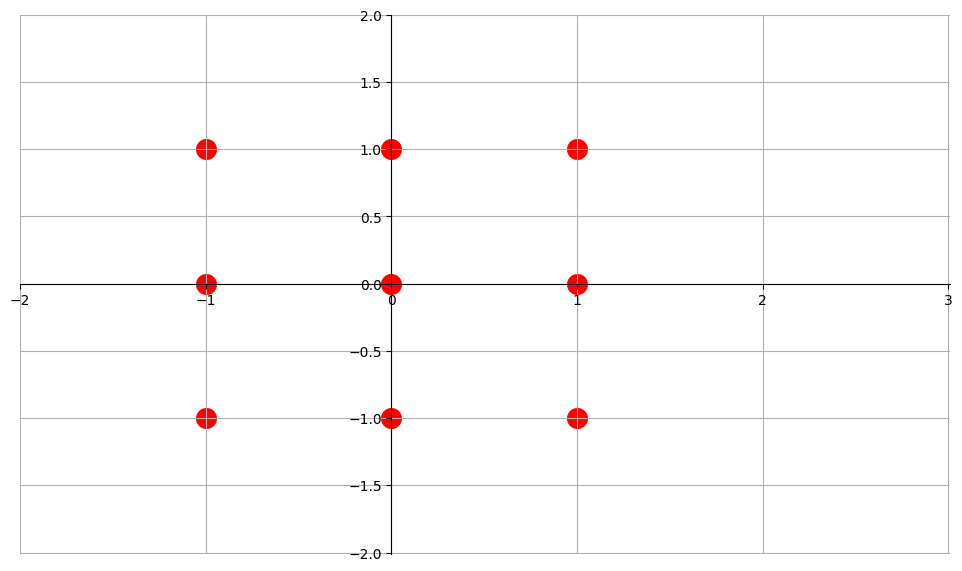

In [4]:
fig, ax = plt.subplots(figsize = (12, 7))
ax.scatter(X, Y, s = 200, color = 'red')
ax.axis([-2, 3.01, -2.01, 2])
ax.spines['left'].set_position('zero') # alternative position is 'center'
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')
ax.grid()
plt.show()

## <font face="gotham" color="purple"> Mencoba Meshgrid yang Lebih Kompleks </font>

Sekarang, mari kita buat **meshgrid yang lebih kompleks** dengan resolusi lebih tinggi.  
Dengan jumlah titik yang lebih banyak, kita bisa melihat struktur grid yang lebih rapat dan halus.


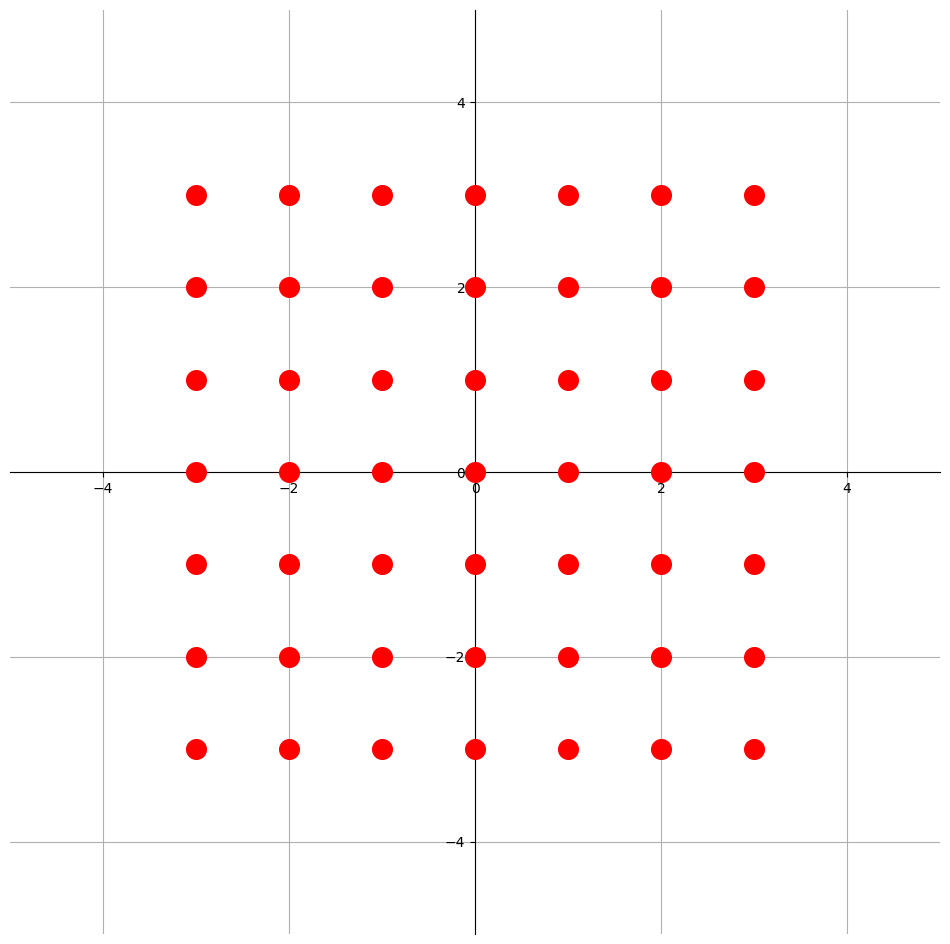

In [5]:
x, y = np.arange(-3, 4, 1), np.arange(-3, 4, 1)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize = (12, 12))
ax.scatter(X, Y, s = 200, color = 'red', zorder = 3)
ax.axis([-5, 5, -5, 5])

ax.spines['left'].set_position('zero') # alternative position is 'center'
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')
ax.grid()

## <font face="gotham" color="purple"> Menggambar Fungsi \( z = f(x, y) \) </font>

Sekarang, pertimbangkan sebuah fungsi \( z = f(x, y) \), di mana \( z \) merepresentasikan **dimensi ke-3**.  
Meskipun **Matplotlib** tidak dirancang untuk pemodelan 3D yang sangat kompleks,  
namun untuk **visualisasi dasar 3D**, pustaka ini sudah sangat memadai.

Sebagai contoh, kita definisikan sebuah bidang sederhana:

$
z = x + y
$

Kemudian kita buat plot untuk \( z \) tersebut.


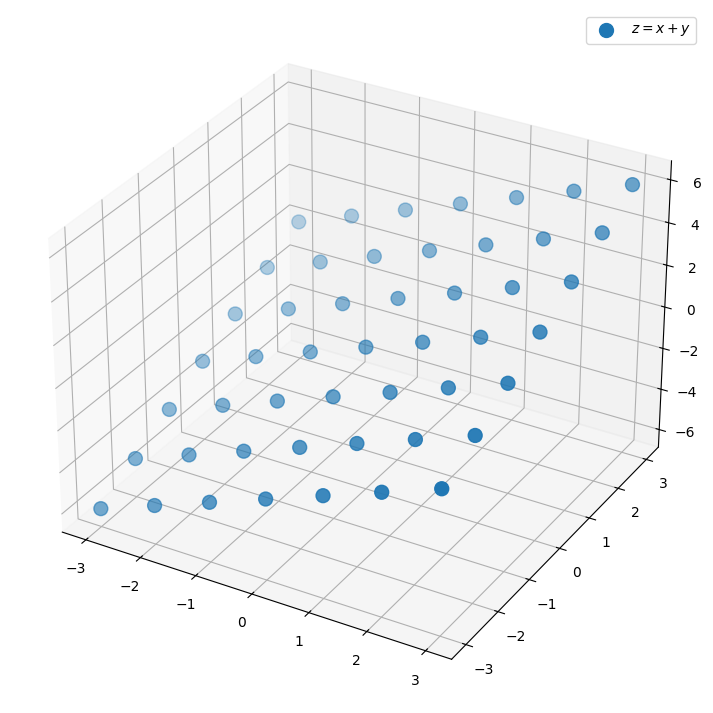

In [6]:
Z = X + Y
fig = plt.figure(figsize = (9,9))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X, Y, Z, s = 100, label = '$z=x+y$')
ax.legend()
plt.show()

## <font face="gotham" color="purple"> Plotting sebagai Permukaan (Surface) </font>

Kita juga dapat mem-plot fungsi \( z = f(x, y) \) dalam bentuk **permukaan (surface)**.  
Dalam hal ini, **Matplotlib** akan secara otomatis melakukan *interpolasi* nilai-nilai di antara  
koordinat Kartesius, sehingga grafik yang dihasilkan tampak halus seperti sebuah permukaan kontinu.


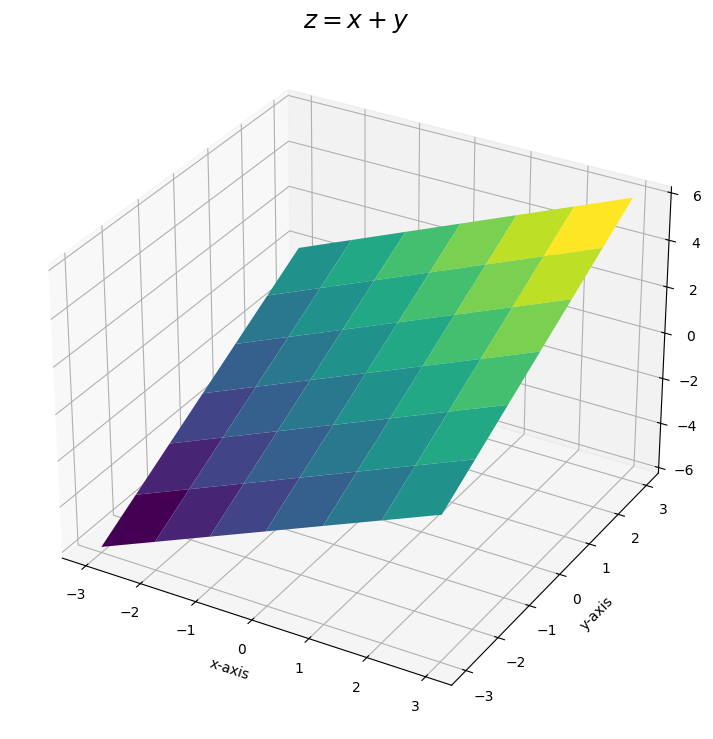

In [7]:
fig = plt.figure(figsize = (9, 9))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, Z, cmap ='viridis') 
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')
ax.set_title('$z=x+y$', size = 18)
plt.show()

# <font face="gotham" color="purple"> Visualisasi Sistem Tiga Persamaan Linear </font>

Sekarang kita akan memvisualisasikan **sistem tiga persamaan linear** dalam ruang 3 dimensi.  
Setiap persamaan merepresentasikan **sebuah bidang**, dan **titik potong ketiganya** (jika ada) merupakan **solusi dari sistem** tersebut.


## <font face="gotham" color="purple"> Visualisasi Sistem Tiga Persamaan Linear </font>

Pertimbangkan sistem persamaan linear berikut:

$
\begin{align}
x_1 - 2x_2 + x_3 &= 0 \\
2x_2 - 8x_3 &= 8 \\
-4x_1 + 5x_2 + 9x_3 &= -9
\end{align}
$

Solusinya adalah:

$
(x_1, x_2, x_3)^T = (29, 16, 3)^T
$

Mari kita gambarkan ketiga bidang tersebut dalam ruang 3 dimensi, dan lihat bagaimana ketiganya berpotongan di satu titik solusi.


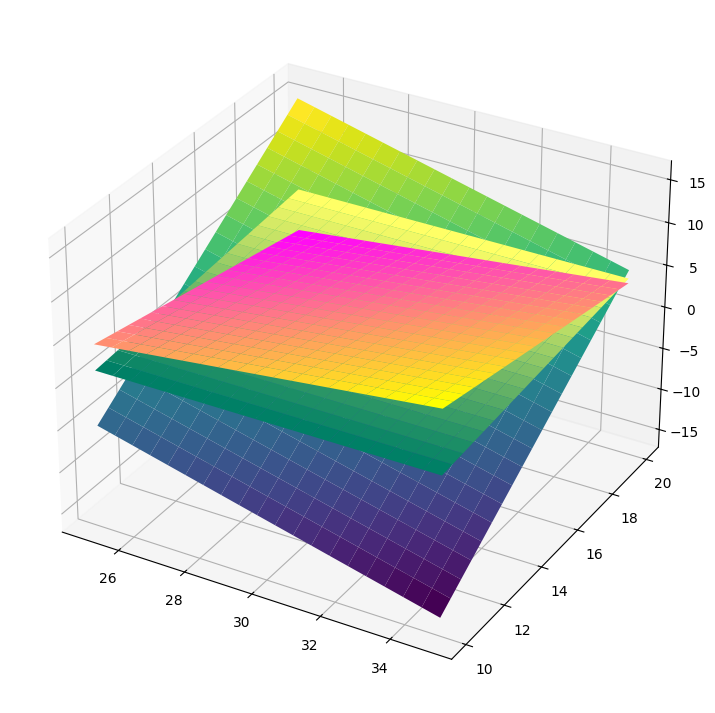

In [8]:
x1 = np.linspace(25, 35, 20)
x2 = np.linspace(10, 20, 20)
X1, X2 = np.meshgrid(x1, x2)

fig = plt.figure(figsize = (9, 9))
ax = fig.add_subplot(111, projection = '3d')

X3 = 2*X2 - X1
ax.plot_surface(X1, X2, X3, cmap ='viridis', alpha = 1) 

X3 = .25*X2 - 1
ax.plot_surface(X1, X2, X3, cmap ='summer', alpha = 1)

X3 = -5/9*X2 + 4/9*X1 - 1
ax.plot_surface(X1, X2, X3, cmap ='spring', alpha = 1)

ax.scatter(29, 16, 3, s = 200, color = 'black')
plt.show()

## <font face="gotham" color="purple"> Mengapa Titik Potong Tidak Terlihat Jelas </font>

Kita yakin bahwa sistem ini memiliki solusi, namun grafik tidak menampilkan titik potong dari bidang-bidang tersebut dengan jelas.  
Masalah ini berasal dari **algoritma render Matplotlib**, yang sebenarnya **tidak dirancang untuk menggambar objek 3D secara nyata**.  
Matplotlib hanya **memproyeksikan objek 3D ke dalam bidang 2D** untuk meniru tampilan tiga dimensi.




## <font face="gotham" color="purple"> Visualisasi Sistem Dengan Jumlah Solusi Tak Hingga </font>

Sekarang, mari kita visualisasikan **sistem persamaan linear yang memiliki solusi tak hingga**.  
Dalam kasus seperti ini, bidang-bidang tidak berpotongan di satu titik, melainkan **berpotongan sepanjang suatu garis**,  
yang merepresentasikan himpunan semua solusi yang memenuhi sistem tersebut.


diberikan sebuah persamaan yaitu 

$
\begin{align}
y-z=&4\\
2x+y+2z=&4\\
2x+2y+z=&8
\end{align}
$

maka solusi dari $z$

$
\begin{align}
z=&y-4\\
z=&2-x-\frac{y}{2}\\
z=&8-2x-2y
\end{align}$

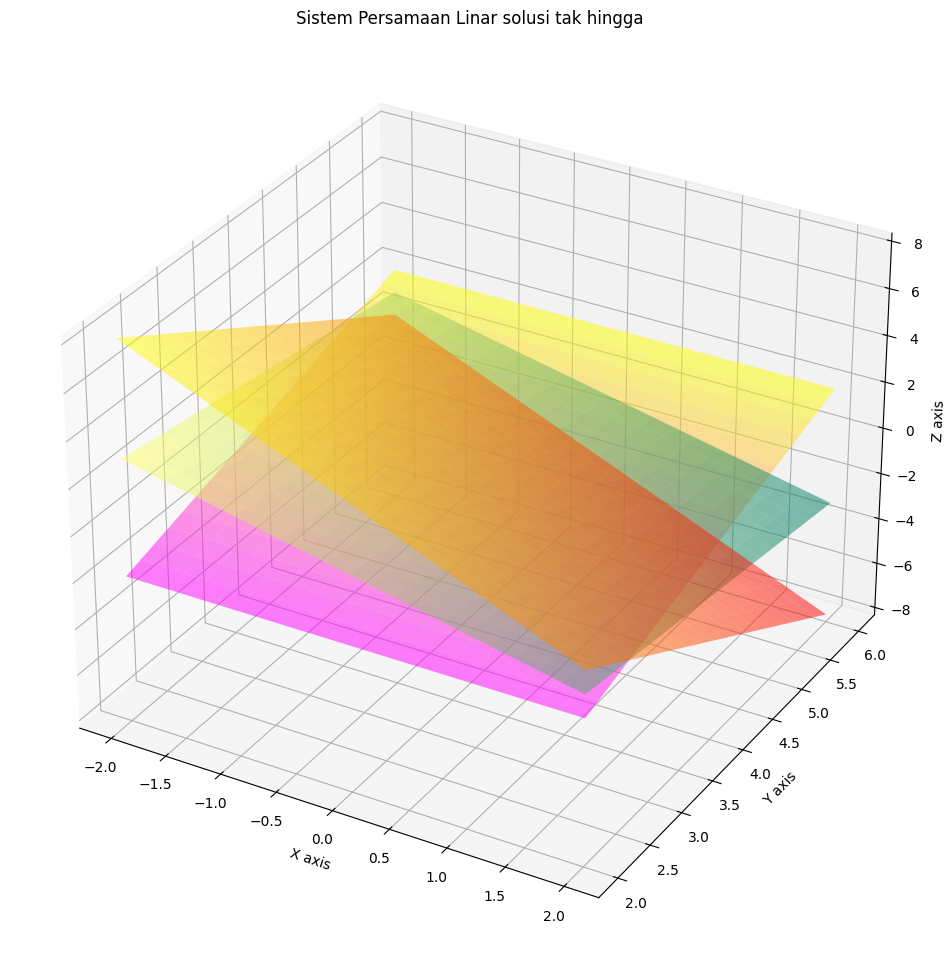

In [9]:

# Mmebuat gambar 3 dimensi 
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Membuat grid
X, Y = np.mgrid[-2:2:21j, 2:6:21j]

# Plot tgarisnya 
Z1 = Y - 4
ax.plot_surface(X, Y, Z1, cmap='spring', alpha=0.5)

# Plot garis kedua 
Z2 = 2 - X - Y/2
ax.plot_surface(X, Y, Z2, cmap='summer', alpha=0.5)

# Plot garis ketiga 
Z3 = 8 - 2*X - 2*Y
ax.plot_surface(X, Y, Z3, cmap='autumn', alpha=0.5)


# menambahaknal label pada masing masing sumbu 
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# tambahkan judul 
plt.title('Sistem Persamaan Linar solusi tak hingga ')

# Menampilkan plot
plt.show()


### <font face="gotham" color="purple"> Garis Solusi Tak Hingga </font>

Solusi dari sistem ini adalah:

$
(x, y, z)^T = \left(-\frac{3z}{2}, \, z + 4, \, z\right)^T
$

dengan \( z \) sebagai **variabel bebas**.

Artinya, sistem ini memiliki **tak hingga banyak solusi** yang membentuk sebuah **garis** di ruang \( \mathbb{R}^3 \).

Untuk memvisualisasikan garis solusi ini, kita dapat menetapkan rentang nilai untuk \( x \) dan \( y \), misalnya:

$
\begin{align}
-2 \leq x \leq 2 \\
2 \leq y \leq 6
\end{align}
$

yang berarti:

$
\begin{align}
-2 \leq -\frac{3}{2}z \leq 2 \\
2 \leq z + 4 \leq 6
\end{align}
$


Kita dapat memilih salah satu ketidaksamaan untuk menetapkan rentang nilai $z$, misalnya ketidaksamaan kedua: $-2 \leq z \leq 2$.  

Setelah itu, plot bidang-bidang dan garis solusi secara bersamaan.


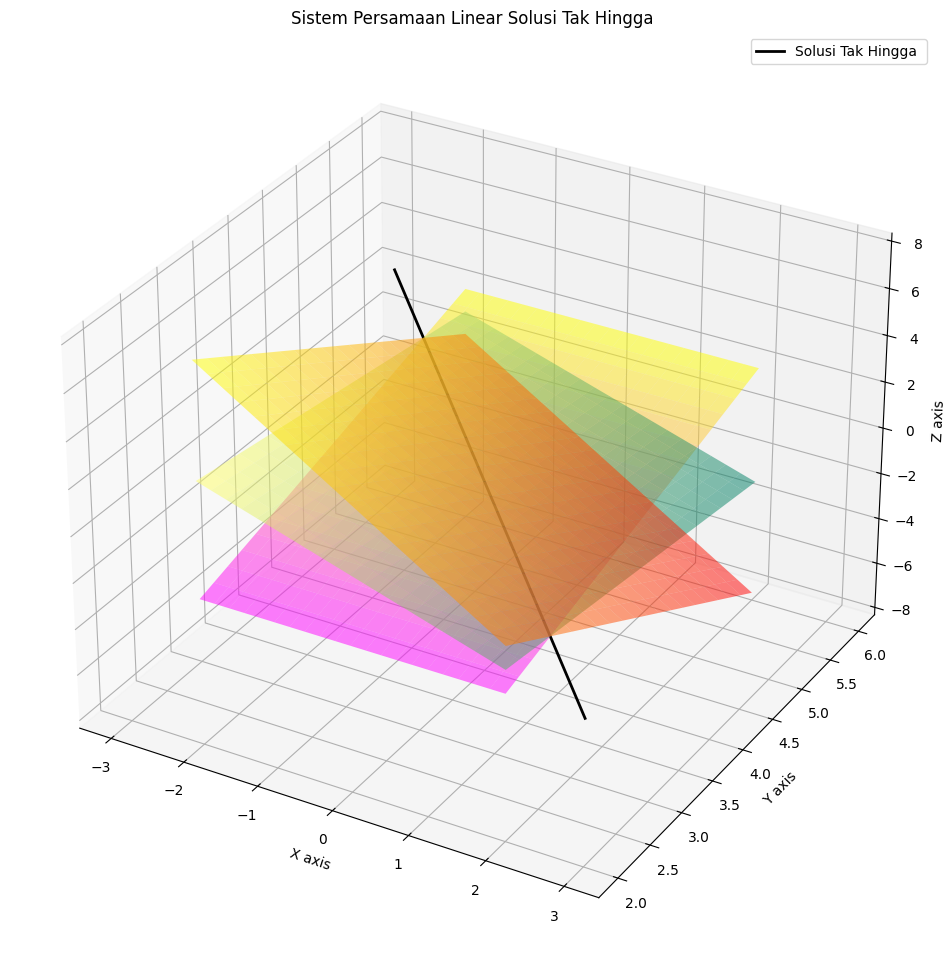

In [10]:

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')


X, Y = np.mgrid[-2:2:21j, 2:6:21j]

Z1 = Y - 4
ax.plot_surface(X, Y, Z1, cmap='spring', alpha=0.5)


Z2 = 2 - X - Y / 2
ax.plot_surface(X, Y, Z2, cmap='summer', alpha=0.5)


Z3 = 8 - 2 * X - 2 * Y
ax.plot_surface(X, Y, Z3, cmap='autumn', alpha=0.5)


ZL = np.linspace(-2, 2, 20)  
XL = -3 * ZL / 2
YL = ZL + 4


ax.plot(XL, YL, ZL, color='black', linewidth=2, label='Solusi Tak Hingga ')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.title('Sistem Persamaan Linear Solusi Tak Hingga')
ax.legend()
plt.show()


# <font face="gotham" color="purple"> Bentuk Eselon Baris Tereduksi (Reduced Row Echelon Form) </font>


Untuk demonstrasi yang lebih mudah, kita akan **sering menggunakan SymPy** dalam perkuliahan.  
SymPy adalah pustaka komputasi simbolik yang sangat kuat, dan kita akan mempelajari fitur-fitur dasarnya seiring berjalannya perkuliahan.


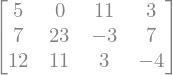

In [11]:
M = sy.Matrix([[5, 0, 11, 3], [7, 23, -3, 7], [12, 11, 3, -4]]); M

Pikirkan ini sebagai sebuah **matriks diperluas (augmented matrix)** yang menggabungkan koefisien dari sistem linear.  
Dengan melakukan **operasi baris**, kita dapat menyelesaikan sistem dengan cepat.  
Mari kita ubah matriks ini menjadi **bentuk eselon baris tereduksi (row reduced echelon form / RREF)**.


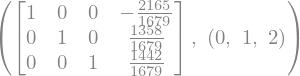

In [12]:
M_rref = M.rref(); M_rref # .rref() is the SymPy method for row reduced echelon form

Ambil elemen pertama di dalam tanda kurung besar, yaitu **matriks RREF**.


In [13]:
M_rref = np.array(M_rref[0]); M_rref

array([[1, 0, 0, -2165/1679],
       [0, 1, 0, 1358/1679],
       [0, 0, 1, 1442/1679]], dtype=object)

Jika kamu tidak suka **pecahan**, ubah matriks menjadi **tipe float**.


In [14]:
M_rref.astype(float)

array([[ 1.   ,  0.   ,  0.   , -1.289],
       [ 0.   ,  1.   ,  0.   ,  0.809],
       [ 0.   ,  0.   ,  1.   ,  0.859]])

Kolom terakhir dari matriks RREF adalah **solusi dari sistem persamaan linear**.


## <font face="gotham" color="purple"> Contoh: RREF dan Visualisasi </font>


Mari kita gunakan metode ```.rref()``` untuk menghitung solusi dari sebuah sistem,  
kemudian memvisualisasikannya. Pertimbangkan sistem berikut:


$\begin{align}
3x+6y+2z&=-13\\
x+2y+z&=-5\\
-5x-10y-2z&=19
\end{align}$

Ekstrak matriks diperluas (augmented matrix) ke dalam sebuah **matriks SymPy**:


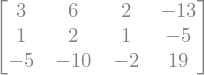

In [15]:
A = sy.Matrix([[3, 6, 2, -13], [1, 2, 1, -5], [-5, -10, -2, 19]]); A

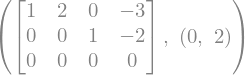

In [16]:
A_rref = A.rref(); A_rref

Jika kamu bertanya-tanya apa arti $(0, 2)$: itu adalah **indeks kolom pivot**.  
Pada matriks diperluas di atas, kolom pivot berada di kolom ke-$0$ dan ke-$2$.


Karena matriks tidak memiliki **rank penuh**, solusi dinyatakan dalam bentuk umum:

$
\begin{align}
x + 2y &= -3 \\
z &= -2 \\
y &= \text{variabel bebas}
\end{align}
$

Untuk memperlihatkan, mari kita pilih tiga nilai berbeda untuk \(y\), yaitu \((3, 5, 7)\), dan hitung tiga solusi unik:


In [17]:
point1 = (-2*3-3, 3, -2)
point2 = (-2*5-3, 5, -2)
point3 = (-2*7-3, 7, -2)
special_solution = np.array([point1, point2, point3]); special_solution # each row is a special solution

array([[ -9,   3,  -2],
       [-13,   5,  -2],
       [-17,   7,  -2]])

In [18]:
y = np.linspace(2, 8, 20) # y is the free variable
x = -3 - 2*y
z = np.full((len(y), ), -2) # z is a constant

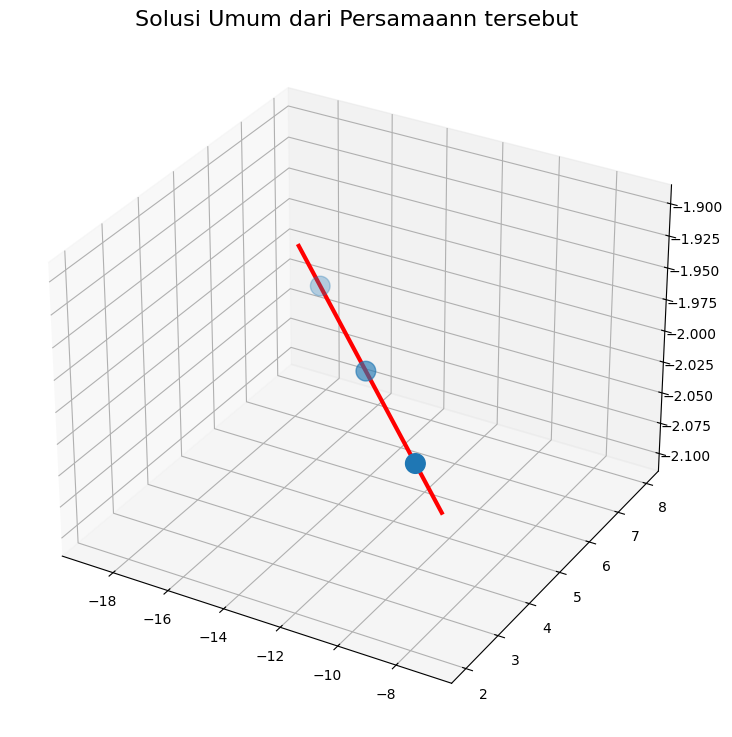

In [19]:
fig = plt.figure(figsize = (12,9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw = 3, color = 'red')
ax.scatter(special_solution[:,0], special_solution[:,1], special_solution[:,2], s = 200)
ax.set_title('Solusi Umum dari Persamaann tersebut', size= 16)
plt.show()

## <font face="gotham" color="purple"> Contoh: Solusi Simbolik </font>


Pertimbangkan sebuah sistem di mana semua nilai di sisi kanan (**right-hand side**) adalah **tidak tentu (indeterminate)**:


\begin{align}
x + 2y - 3z &= a\\
4x - y + 8z &= b\\
2x - 6y - 4z &= c
\end{align}

Kita mendefinisikan $a, b, c$ sebagai objek **SymPy**, lalu mengekstrak **matriks diperluas (augmented matrix)**.


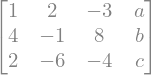

In [20]:
a, b, c = sy.symbols('a, b, c', real = True)
A = sy.Matrix([[1, 2, -3, a], [4, -1, 8, b], [2, -6, -4, c]]); A

Kita dapat langsung memperoleh **solusi simbolik** dengan menggunakan metode ```.rref()``` .


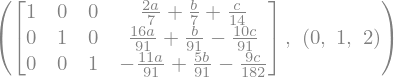

In [21]:
A_rref = A.rref(); A_rref

Of course, we can substitute values of $a$, $b$ and $c$ to get a specific solution. 

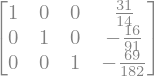

In [22]:
spec_solution = {a: 3, b: 6, c: 7}
A_rref = A_rref[0].subs(spec_solution); A_rref 

## <font face="gotham" color="purple"> Contoh: Polinomial </font>


Untuk menentukan sebuah polinomial kubik yang melalui titik-titik $(1,3)$, $(2,-2)$, $(3,-5)$, dan $(4,0)$,  
kita pertimbangkan bentuk umum polinomial kubik:

$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3
$

Dengan mensubstitusi setiap titik ke dalam persamaan ini, kita memperoleh sistem persamaan:

$
\begin{align}
3 &= a_0 + a_1(1) + a_2(1)^2 + a_3(1)^3 \\
-2 &= a_0 + a_1(2) + a_2(2)^2 + a_3(2)^3 \\
-5 &= a_0 + a_1(3) + a_2(3)^2 + a_3(3)^3 \\
0 &= a_0 + a_1(4) + a_2(4)^2 + a_3(4)^3
\end{align}
$



Matriks diperluas (augmented matrix) dari sistem ini adalah:


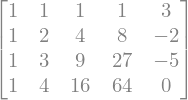

In [23]:
A = sy.Matrix([[1, 1, 1, 1, 3], [1, 2, 4, 8, -2], [1, 3, 9, 27, -5], [1, 4, 16, 64, 0]]); A

In [24]:
A_rref = A.rref(); A_rref
poly_coef = [A_rref[0][i, -1] for i in range(A_rref[0].shape[0])]

Since we have the specific form of the cubic polynomial, we can plot it

In [25]:
A_rref
x = np.linspace(-5, 5, 40)
y = poly_coef[0] + poly_coef[1]*x + poly_coef[2]*x**2 + poly_coef[3]*x**3

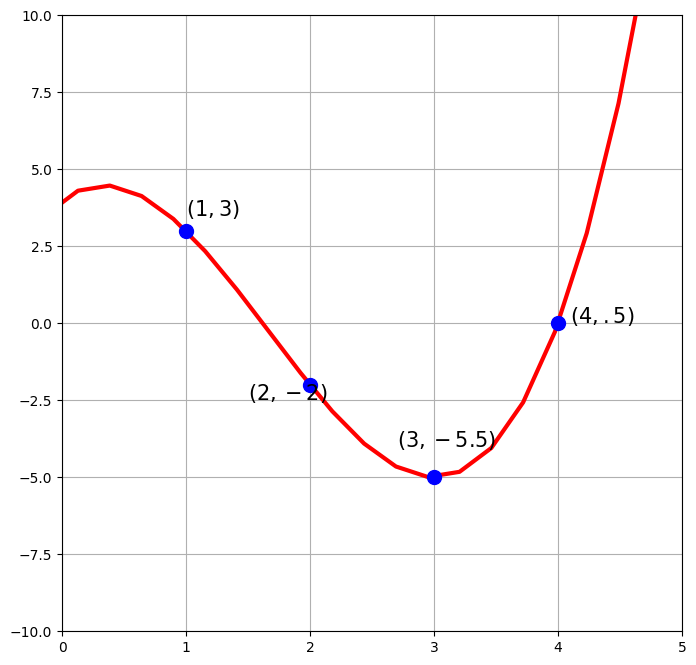

In [26]:
fig, ax = plt.subplots(figsize = (8, 8))
ax.plot(x, y, lw = 3, color ='red')
ax.scatter([1, 2, 3, 4], [3, -2, -5, 0], s = 100, color = 'blue', zorder = 3)
ax.grid()
ax.set_xlim([0, 5])
ax.set_ylim([-10, 10])

ax.text(1, 3.5, '$(1, 3)$', fontsize = 15)
ax.text(1.5, -2.5, '$(2, -2)$', fontsize = 15)
ax.text(2.7, -4, '$(3, -5.5)$', fontsize = 15)
ax.text(4.1, 0, '$(4, .5)$', fontsize = 15)
plt.show()

Now you know the trick, try another 5 points: $(1,2)$, $(2,5)$, $(3,8)$, $(4,6)$, $(5, 9)$. And polynomial form is 
$$
\begin{align}
y=a_0+a_1x+a_2x^2+a_3x^3+a_4x^4
\end{align}
$$
The augmented matrix is

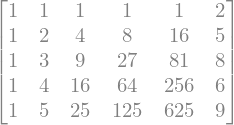

In [27]:
A = sy.Matrix([[1, 1, 1, 1, 1, 2],
               [1, 2, 4, 8, 16, 5], 
               [1, 3, 9, 27, 81, 8], 
               [1, 4, 16, 64, 256, 6], 
               [1, 5, 25,125, 625, 9]]); A

In [28]:
A_rref = A.rref()
A_rref = np.array(A_rref[0])
coef = A_rref.astype(float)[:,-1];coef

array([ 19.   , -37.417,  26.875,  -7.083,   0.625])

In [29]:
x = np.linspace(0, 6, 100)
y = coef[0] + coef[1]*x + coef[2]*x**2 + coef[3]*x**3 + coef[4]*x**4

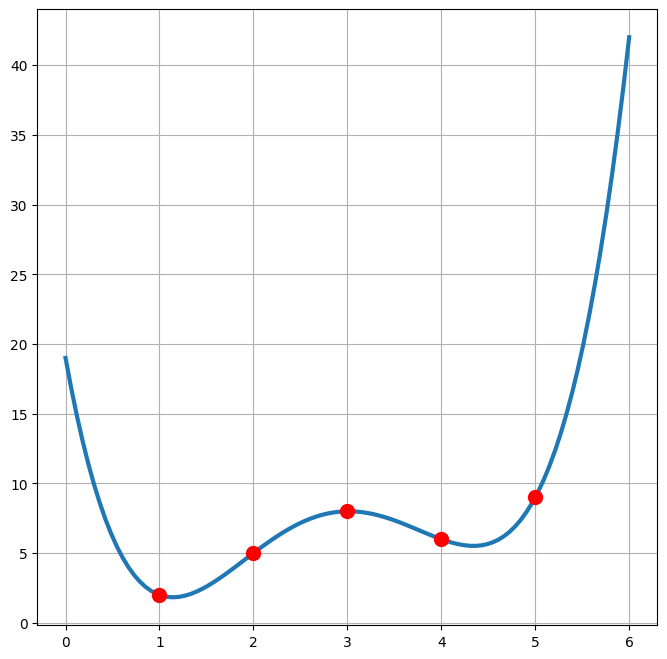

In [30]:
fig, ax = plt.subplots(figsize= (8, 8))
ax.plot(x, y, lw =3)
ax.scatter([1, 2, 3, 4, 5], [2, 5, 8, 6, 9], s= 100, color = 'red', zorder = 3)
ax.grid()

# <font face="gotham" color="purple"> Menyelesaikan Sistem Persamaan Linear dengan NumPy </font>


Siapkan sistem $A x = b$, lalu buat secara acak matriks $A$ dan vektor $b$.


In [31]:
A = np.round(10 * np.random.rand(5, 5))
b = np.round(10 * np.random.rand(5,))

In [32]:
x = np.linalg.solve(A, b); x

array([ 0.685,  4.761,  2.03 , -1.719, -3.103])

Let's verify if $ Ax = b$

In [33]:
A@x - b

array([ 0.,  0., -0.,  0.,  0.])

Secara teknis, nilai-nilai tersebut adalah nol, karena ada beberapa kesalahan pembulatan yang diabaikan; itulah sebabnya terdapat tanda $-$ di depan $0$.


## <font face="gotham" color="purple"> Kesimpulan </font>

Dari proyek ini, dapat disimpulkan bahwa:

1. **Sistem persamaan linear** dapat divisualisasikan dalam 2D maupun 3D,  
   baik sebagai garis (2 variabel) maupun bidang (3 variabel).

2. **Matematika simbolik dengan SymPy** mempermudah perhitungan:  
   - Membuat **matriks diperluas (augmented matrix)**  
   - Mengubah ke **Reduced Row Echelon Form (RREF)**  
   - Menentukan **solusi numerik atau simbolik**  
   - Mengidentifikasi **pivot columns** dan **variabel bebas**

3. **Sistem dengan solusi tak hingga** dapat divisualisasikan sebagai **garis solusi** di ruang 3D.

4. **Polinomial kubik** dapat ditentukan dari beberapa titik dengan membentuk sistem linear,  
   kemudian diselesaikan menggunakan RREF untuk mendapatkan koefisiennya.

5. Kombinasi **visualisasi grafis** dan **perhitungan simbolik** sangat membantu dalam memahami aljabar linear dan interpolasi polinomial.

